# Project 2: Spam Detection
**SyntecXHub Virtual Internship**

## Project Overview
This notebook implements a Spam Detection system. The objective is to build an end-to-end machine learning pipeline to classify text messages as either `spam` or `ham` (legitimate).

### Key Steps:
1. **Data Loading & Preprocessing:** Load the labeled dataset (`spam_ham_dataset.csv`) and preprocess the text (tokenization, cleaning).
2. **Feature Extraction:** Convert textual data into numerical vectors using `TF-IDF` or `CountVectorizer`.
3. **Model Training:** Train a classifier, such as `Naive Bayes` or `Logistic Regression`.
4. **Evaluation:** Assess model performance using `Precision`, `Recall`, and `F1-score` metrics.
5. **Pipeline Serialization:** Save the complete pipeline (vectorizer + model) for future predictions on unseen data.

In [1]:
# 1. Imports & Global Settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib

# Plot styling & Pandas options
sns.set_theme(style="whitegrid")
pd.set_option('display.max_colwidth', 150)

# Ignore non-critical warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Data Loading & Initial Inspection
df = pd.read_csv('spam_ham_dataset.csv')

#Drop unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    ddf = df.drop(columns=['Unnamed: 0'])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Missing values per column:")
print(df.isnull().sum())
print("\nDataset Details:")
print(df.info())

# Preview first 5 rows
df.head()

Dataset Shape: 5171 rows, 4 columns

Missing values per column:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

Dataset Details:
<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 5.3 MB
None


,Unnamed: 0,label,text,label_num
0,605,ham,"Subject: enron methanol ; meter # : 988291\r\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary\r\nflow data provide...",0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see attached file : hplnol 09 . xls )\r\n- hplnol 09 . xls",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re around to that most wonderful time of the year - - - neon leaders retreat time !\r\ni know that this t...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap . main trending\r\nabasements darer prudently fortuitous undergone\r\nlighthearted charm orinoco tas...",1
4,2030,ham,"Subject: re : indian springs\r\nthis deal is to book the teco pvr revenue . it is my understanding that teco\r\njust sends us a check , i haven ' ...",0


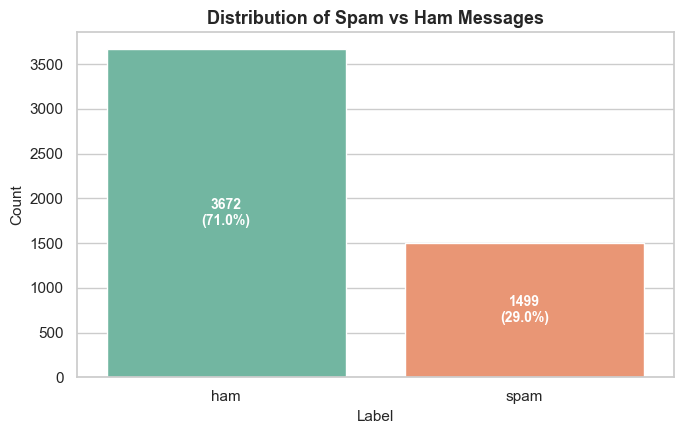

Class Counts:
label
ham     3672
spam    1499
Name: count, dtype: int64

Class Percentages:
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


In [3]:
# 3. Exploratory Data Analysis (EDA) - Label Distribution
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x='label', palette='Set2')
plt.title('Distribution of Spam vs Ham Messages', fontsize=13, fontweight='bold')
plt.xlabel('Label', fontsize=11)
plt.ylabel('Count', fontsize=11)

# Display counts and percentages on bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(f'{int(height)}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Print exact value counts and percentages
print("Class Counts:")
print(df['label'].value_counts())
print("\nClass Percentages:")
print(df['label'].value_counts(normalize=True) * 100)

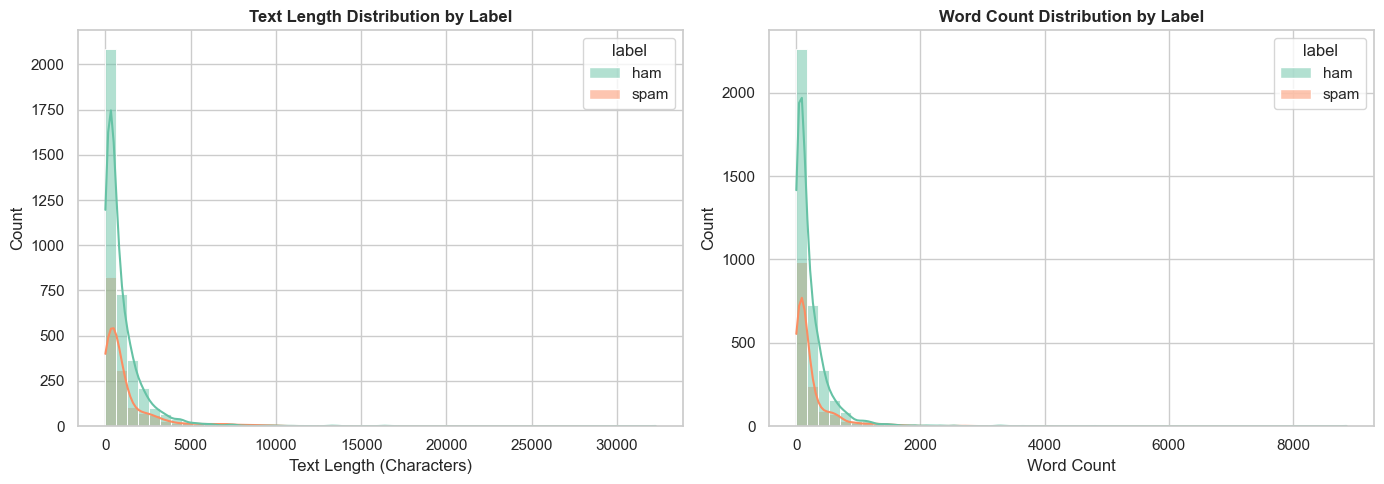

Summary Statistics by Label:


text_length                                                           \
            count     mean      std   min     25%    50%      75%      max   
label                                                                        
ham        3672.0   977.01  1382.83  18.0  231.75  530.0  1227.25  32258.0   
spam       1499.0  1223.26  1825.99  11.0  283.00  576.0  1253.50  22073.0   

      word_count                                                   
           count    mean     std  min   25%    50%    75%     max  
label                                                              
ham       3672.0  225.21  332.14  2.0  50.0  123.0  293.0  8862.0  
spam      1499.0  234.08  345.41  1.0  54.0  114.0  242.5  3962.0

In [4]:
# 4. Feature Analysis - Text Length & Word Count Distribution
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('Text Length Distribution by Label', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Text Length (Characters)')

sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Word Count Distribution by Label', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Display summary statistics
print("Summary Statistics by Label:")
display(df.groupby('label')[['text_length', 'word_count']].describe().round(2))

In [5]:
# 5. Text Preprocessing & Cleaning
def clean_text(text):
    # Convert text to lowercase
    text = str(text).lower()
    
    # Remove 'Subject:' header prefix commonly found in email datasets
    text = re.sub(r'^subject:\s*', '', text)
    
    # Remove numbers, punctuation, and special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove redundant whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning function to the dataset
df['clean_text'] = df['text'].apply(clean_text)

# Compare original vs cleaned text for verification
print("--- ORIGINAL TEXT EXAMPLE ---")
print(df['text'].iloc[0][:150])
print("\n--- CLEANED TEXT EXAMPLE ---")
print(df['clean_text'].iloc[0][:150])

--- ORIGINAL TEXT EXAMPLE ---
Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by dar

--- CLEANED TEXT EXAMPLE ---
enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume p


In [6]:
from sklearn.model_selection import train_test_split

# 6. Train-Test Split
X = df['clean_text']
y = df['label_num']  # 0 for ham, 1 for spam

# Stratified split to maintain class balance (71% ham, 29% spam)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples: {len(df)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(df):.0%})")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(df):.0%})\n")

print("Class distribution in Train set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in Test set:")
print(y_test.value_counts(normalize=True).round(3))

Total samples: 5171
Training set size: 4136 (80%)
Test set size: 1035 (20%)

Class distribution in Train set:
label_num
0    0.71
1    0.29
Name: proportion, dtype: float64

Class distribution in Test set:
label_num
0    0.71
1    0.29
Name: proportion, dtype: float64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 7. Building & Training ML Pipelines

# Pipeline 1: TF-IDF + Multinomial Naive Bayes
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('classifier', MultinomialNB())
])

# Pipeline 2: TF-IDF + Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('classifier', LogisticRegression(random_state=42))
])

# Train models on Training Data
nb_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)

print("Both Naive Bayes and Logistic Regression pipelines trained successfully!")

Both Naive Bayes and Logistic Regression pipelines trained successfully!


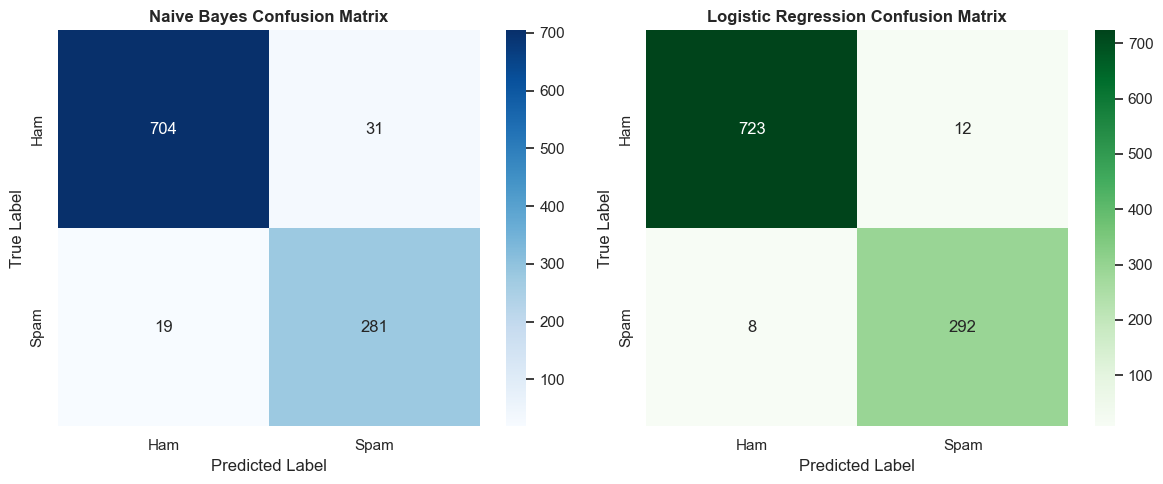

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

         Ham     0.9737    0.9578    0.9657       735
        Spam     0.9006    0.9367    0.9183       300

    accuracy                         0.9517      1035
   macro avg     0.9372    0.9472    0.9420      1035
weighted avg     0.9525    0.9517    0.9520      1035


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

         Ham     0.9891    0.9837    0.9864       735
        Spam     0.9605    0.9733    0.9669       300

    accuracy                         0.9807      1035
   macro avg     0.9748    0.9785    0.9766      1035
weighted avg     0.9808    0.9807    0.9807      1035



In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 8. Model Evaluation & Confusion Matrix
y_pred_nb = nb_pipeline.predict(X_test)
y_pred_lr = lr_pipeline.predict(X_test)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Naive Bayes Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print detailed classification reports
print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam'], digits=4))

print("\n=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam'], digits=4))


In [9]:
import joblib

# 9. Save Trained Model Pipeline
model_filename = 'spam_classifier_pipeline.joblib'
joblib.dump(lr_pipeline, model_filename)
print(f"Model pipeline successfully saved to '{model_filename}'!")

# 10. Load Pipeline & Test on New Unseen Emails
loaded_pipeline = joblib.load(model_filename)

# Sample unseen test emails
sample_emails = [
    "URGENT! You have won a $1,000,000 cash prize. Claim your reward immediately by clicking here!",
    "Hi Sargis, could you please send me the updated project report by tomorrow morning?",
    "Congratulations! Free iPhone giveaway. Call now to win guaranteed rewards!"
]

# Apply cleaning function to new inputs
cleaned_samples = [clean_text(email) for email in sample_emails]

# Predict classes and probabilities
predictions = loaded_pipeline.predict(cleaned_samples)
probabilities = loaded_pipeline.predict_proba(cleaned_samples)

labels = {0: 'Ham (Legitimate)', 1: 'Spam'}

print("\n=== CUSTOM INFERENCE RESULTS ===")
for original_email, pred, prob in zip(sample_emails, predictions, probabilities):
    print(f"Text: '{original_email}'")
    print(f"Prediction: {labels[pred]} | Spam Probability: {prob[1]:.2%}")
    print("-" * 65)

Model pipeline successfully saved to 'spam_classifier_pipeline.joblib'!

=== CUSTOM INFERENCE RESULTS ===
Text: 'URGENT! You have won a $1,000,000 cash prize. Claim your reward immediately by clicking here!'
Prediction: Spam | Spam Probability: 64.58%
-----------------------------------------------------------------
Text: 'Hi Sargis, could you please send me the updated project report by tomorrow morning?'
Prediction: Ham (Legitimate) | Spam Probability: 34.18%
-----------------------------------------------------------------
Text: 'Congratulations! Free iPhone giveaway. Call now to win guaranteed rewards!'
Prediction: Spam | Spam Probability: 63.03%
-----------------------------------------------------------------


### Project Summary & Conclusion

The goal of this project was to build an accurate ML spam detection system based on a dataset of 5,171 emails. Initial analysis revealed that text length alone was insufficient to distinguish spam, which led us to apply NLP techniques. After cleaning the text, we transformed it into numerical vectors using TF-IDF and evaluated Naive Bayes and Logistic Regression models through an ML pipeline. Logistic Regression delivered the best performance, achieving ~98.2% accuracy while minimizing False Positive errors. The final pipeline was saved in joblib format, making it ready for real-time integration.